# YouTube Watch + Search History Analysis (Google Takeout)

## Project Goal
Convert non-tabular Google Takeout JSON exports into structured datasets
for behavioural analysis.

## Data Sources 
- `data/watch-history.json` — every video watched
- `data/search-history.json` — every YouTube search

## Privacy Note
Raw JSON files are listed in `.gitignore` and must **never** be committed to GitHub.  
Only aggregated outputs (counts by month/year, top channels, etc.) are exported to `data_processed/`.

---
## Analysis Workflow

This notebook follows a structured data analysis pipeline:

1. **Imports & Setup**  
   Load required libraries, configure visualization styles, and define file paths.

2. **Load Raw Data**  
   Read Google Takeout watch and search history JSON files.

3. **Watch History Processing**  
   Normalize nested JSON into tabular format and generate time features:
   year, month, day of week, and hour.

4. **Search History Processing**  
   Clean search queries and create matching datetime features for comparison.

5. **Combined Activity Dataset**  
   Merge watch and search activity into a unified analytical dataset.

6. **Viewing Behaviour Analysis**  
   Analyze and visualize watching patterns by day of week and hour of day.

7. **Top Channels Analysis**  
   Identify the most frequently watched YouTube channels.

8. **Search Behaviour Analysis**  
   Examine search frequency trends and user intent patterns.

9. **Year-over-Year Comparisons**  
   Compare activity across years and visualize trends using monthly heatmaps.

10. **Content Theme Analysis**  
    Categorize videos using keyword-based classification to identify dominant content themes.

11. **Export Results**  
    Save aggregated, privacy-safe datasets for public sharing and reproducibility.


## 1. Imports & Visual Theme

In [115]:
import json
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from IPython.display import display

#File paths
BASE_DIR    = Path().resolve().parent 
DATA_DIR    = BASE_DIR / "data"
WATCH_FILE  = DATA_DIR / "watch-history.json"
SEARCH_FILE = DATA_DIR / "search-history.json"

print(f"   Watch file  : {WATCH_FILE}")
print(f"   Search file : {SEARCH_FILE}")


   Watch file  : C:\Users\aisen\Documents\youtube-behavior-analysis\data\watch-history.json
   Search file : C:\Users\aisen\Documents\youtube-behavior-analysis\data\search-history.json


## 2. Load the Raw JSON Exports
Both files are loaded as Python lists. We check lengths before touching any data.

In [116]:
def load_json(path: Path):
    with path.open(encoding="utf-8") as f:
        return json.load(f)

watch_raw = load_json(WATCH_FILE)

if SEARCH_FILE.exists():
    search_raw = load_json(SEARCH_FILE)
else:
    search_raw = []

print(f"Watch  records : {len(watch_raw):>8,}")
print(f"Search records : {len(search_raw):>8,}")


Watch  records :   13,700
Search records :   15,300


## 3. Normalize Watch History into a Table
`pd.json_normalize` flattens the nested JSON in one call. We preview column names and types.

In [117]:
watch_df = pd.json_normalize(watch_raw)
print("Shape:", watch_df.shape)
print("Columns:", watch_df.columns.tolist())
watch_df.head(3)


Shape: (13700, 9)
Columns: ['header', 'title', 'titleUrl', 'subtitles', 'time', 'products', 'activityControls', 'description', 'details']


,header,title,titleUrl,subtitles,time,products,activityControls,description,details
0,YouTube,Watched ВСЕ ФИФЕРЫ В СБОРЕ! ДНЮХА PANDAFX.,https://www.youtube.com/watch?v=maeRmqMqBQk,"[{'name': 'PANDAFX', 'url': 'https://www.youtu...",2026-02-28T20:59:13.860Z,[YouTube],[YouTube watch history],NaN,NaN
1,YouTube,"Watched Он весил 50кг, а его не мог поднять да...",https://www.youtube.com/watch?v=ryvmCNqYFoc,"[{'name': 'Легенды Спорта', 'url': 'https://ww...",2026-02-28T20:58:50.535Z,[YouTube],[YouTube watch history],NaN,NaN
2,YouTube,Watched THE FIRST FUT DRAFT EVER!! - RETRO FIFA,https://www.youtube.com/watch?v=3jmDw1j29z0,"[{'name': 'W2S', 'url': 'https://www.youtube.c...",2026-02-28T20:53:09.238Z,[YouTube],[YouTube watch history],NaN,NaN


## Clean + Feature-Engineer Watch History
- Rename columns to snake_case
- Extract channel name from the nested `subtitles` list
- Strip the `"Watched "` prefix from video titles
- Parse ISO timestamps → datetime; derive year / month / day / hour


In [118]:
# Standardize column names
watch_df = watch_df.rename(columns={
    "title":    "raw_title",
    "titleUrl": "video_url",
    "time":     "datetime_str",
})

# Channel name 
def get_channel(subtitles):
    if isinstance(subtitles, list) and len(subtitles) > 0:
        return subtitles[0].get("name")
    return None

watch_df["channel_name"] = watch_df["subtitles"].apply(get_channel)

# Clean title 
def clean_title(raw):
    if not isinstance(raw, str):
        return None
    return re.sub(r"^Watched\s+", "", raw, flags=re.IGNORECASE).strip()

watch_df["video_title"] = watch_df["raw_title"].apply(clean_title)

# Timestamps 
watch_df["datetime"]    = pd.to_datetime(watch_df["datetime_str"], errors="coerce", utc=True)
watch_df["date"]        = watch_df["datetime"].dt.date
watch_df["year"]        = watch_df["datetime"].dt.year.astype("Int64")
watch_df["month"]       = watch_df["datetime"].dt.to_period("M").astype(str)
watch_df["month_dt"]    = pd.to_datetime(watch_df["month"])
watch_df["month_num"]   = watch_df["datetime"].dt.month
watch_df["day_of_week"] = watch_df["datetime"].dt.day_name()
watch_df["hour"]        = watch_df["datetime"].dt.hour.astype("Int64")
watch_df["is_weekend"]  = watch_df["day_of_week"].isin(["Saturday", "Sunday"])
watch_df["source"]      = "watch"

# Keep only records that are actual video watches
watch_df = watch_df[watch_df["video_url"].str.contains("watch\\?v=", na=False)]

COLS = [
    "datetime", "date", "year", "month", "month_dt", "month_num",
    "day_of_week", "hour", "is_weekend",
    "video_title", "video_url", "channel_name", "source"
]
watch_df = watch_df[COLS].dropna(subset=["datetime"])

print(f"Clean watch records: {len(watch_df):,}")
watch_df.head(3)


Clean watch records: 12,727


C:\Users\aisen\AppData\Local\Temp\ipykernel_21968\1433850238.py:28: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  watch_df["month"]       = watch_df["datetime"].dt.to_period("M").astype(str)


,datetime,date,year,month,month_dt,month_num,day_of_week,hour,is_weekend,video_title,video_url,channel_name,source
0,2026-02-28 20:59:13.860000+00:00,2026-02-28,2026,2026-02,2026-02-01,2.0,Saturday,20,True,ВСЕ ФИФЕРЫ В СБОРЕ! ДНЮХА PANDAFX.,https://www.youtube.com/watch?v=maeRmqMqBQk,PANDAFX,watch
1,2026-02-28 20:58:50.535000+00:00,2026-02-28,2026,2026-02,2026-02-01,2.0,Saturday,20,True,"Он весил 50кг, а его не мог поднять даже Мухам...",https://www.youtube.com/watch?v=ryvmCNqYFoc,Легенды Спорта,watch
2,2026-02-28 20:53:09.238000+00:00,2026-02-28,2026,2026-02,2026-02-01,2.0,Saturday,20,True,THE FIRST FUT DRAFT EVER!! - RETRO FIFA,https://www.youtube.com/watch?v=3jmDw1j29z0,W2S,watch


## 4. Normalize + Clean Search History
Extract the search query text and apply the same timestamp engineering.

In [119]:
if SEARCH_FILE.exists():
    search_df = pd.json_normalize(search_raw)
    search_df = search_df.rename(columns={"title": "raw_title", "time": "datetime_str"})

    def extract_query(raw):
        if not isinstance(raw, str):
            return None
        prefix = "Searched for "
        return raw[len(prefix):] if raw.startswith(prefix) else None

    search_df["search_query"] = search_df["raw_title"].apply(extract_query)
    search_df = search_df[search_df["search_query"].notna()].copy()

    search_df["datetime"]    = pd.to_datetime(search_df["datetime_str"], errors="coerce", utc=True)
    search_df["date"]        = search_df["datetime"].dt.date
    search_df["year"]        = search_df["datetime"].dt.year.astype("Int64")
    search_df["month"]       = search_df["datetime"].dt.to_period("M").astype(str)
    search_df["month_dt"]    = pd.to_datetime(search_df["month"])
    search_df["day_of_week"] = search_df["datetime"].dt.day_name()
    search_df["hour"]        = search_df["datetime"].dt.hour.astype("Int64")
    search_df["source"]      = "search"

    search_df = search_df[
        ["datetime", "date", "year", "month", "month_dt",
         "day_of_week", "hour", "search_query", "source"]
    ].dropna(subset=["datetime"])

    print(f" Clean search records: {len(search_df):,}")
else:
    search_df = pd.DataFrame()
    print("⚠️  search-history.json not found — search sections will be skipped.")

search_df.head(3)


 Clean search records: 3,704


C:\Users\aisen\AppData\Local\Temp\ipykernel_21968\2579778477.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  search_df["month"]       = search_df["datetime"].dt.to_period("M").astype(str)


,datetime,date,year,month,month_dt,day_of_week,hour,search_query,source
16,2026-02-28 08:04:02.948000+00:00,2026-02-28,2026,2026-02,2026-02-01,Saturday,8,acoolfifa,search
31,2026-02-27 19:17:33.360000+00:00,2026-02-27,2026,2026-02,2026-02-01,Friday,19,ахтунг ахтунг,search
34,2026-02-27 14:48:51.866000+00:00,2026-02-27,2026,2026-02,2026-02-01,Friday,14,гимн якутии,search


## 5. Combined Activity Table
Merge watch + search into one DataFrame for side-by-side comparisons.

In [120]:
if not search_df.empty:
    df = pd.concat([watch_df, search_df], ignore_index=True, sort=False)
else:
    df = watch_df.copy()

print(f"Combined shape: {df.shape}")
print(df["source"].value_counts().to_string())
df.head(3)


Combined shape: (16431, 14)
source
watch     12727
search     3704


,datetime,date,year,month,month_dt,month_num,day_of_week,hour,is_weekend,video_title,video_url,channel_name,source,search_query
0,2026-02-28 20:59:13.860000+00:00,2026-02-28,2026,2026-02,2026-02-01,2.0,Saturday,20,True,ВСЕ ФИФЕРЫ В СБОРЕ! ДНЮХА PANDAFX.,https://www.youtube.com/watch?v=maeRmqMqBQk,PANDAFX,watch,NaN
1,2026-02-28 20:58:50.535000+00:00,2026-02-28,2026,2026-02,2026-02-01,2.0,Saturday,20,True,"Он весил 50кг, а его не мог поднять даже Мухам...",https://www.youtube.com/watch?v=ryvmCNqYFoc,Легенды Спорта,watch,NaN
2,2026-02-28 20:53:09.238000+00:00,2026-02-28,2026,2026-02,2026-02-01,2.0,Saturday,20,True,THE FIRST FUT DRAFT EVER!! - RETRO FIFA,https://www.youtube.com/watch?v=3jmDw1j29z0,W2S,watch,NaN


## 6. Viewing Patterns
Three views of *when* you watch:
1. Number of videos by day-of-week
2. Number of videos by hour-of-day  
3. Combined **day × hour heatmap** (the most revealing)


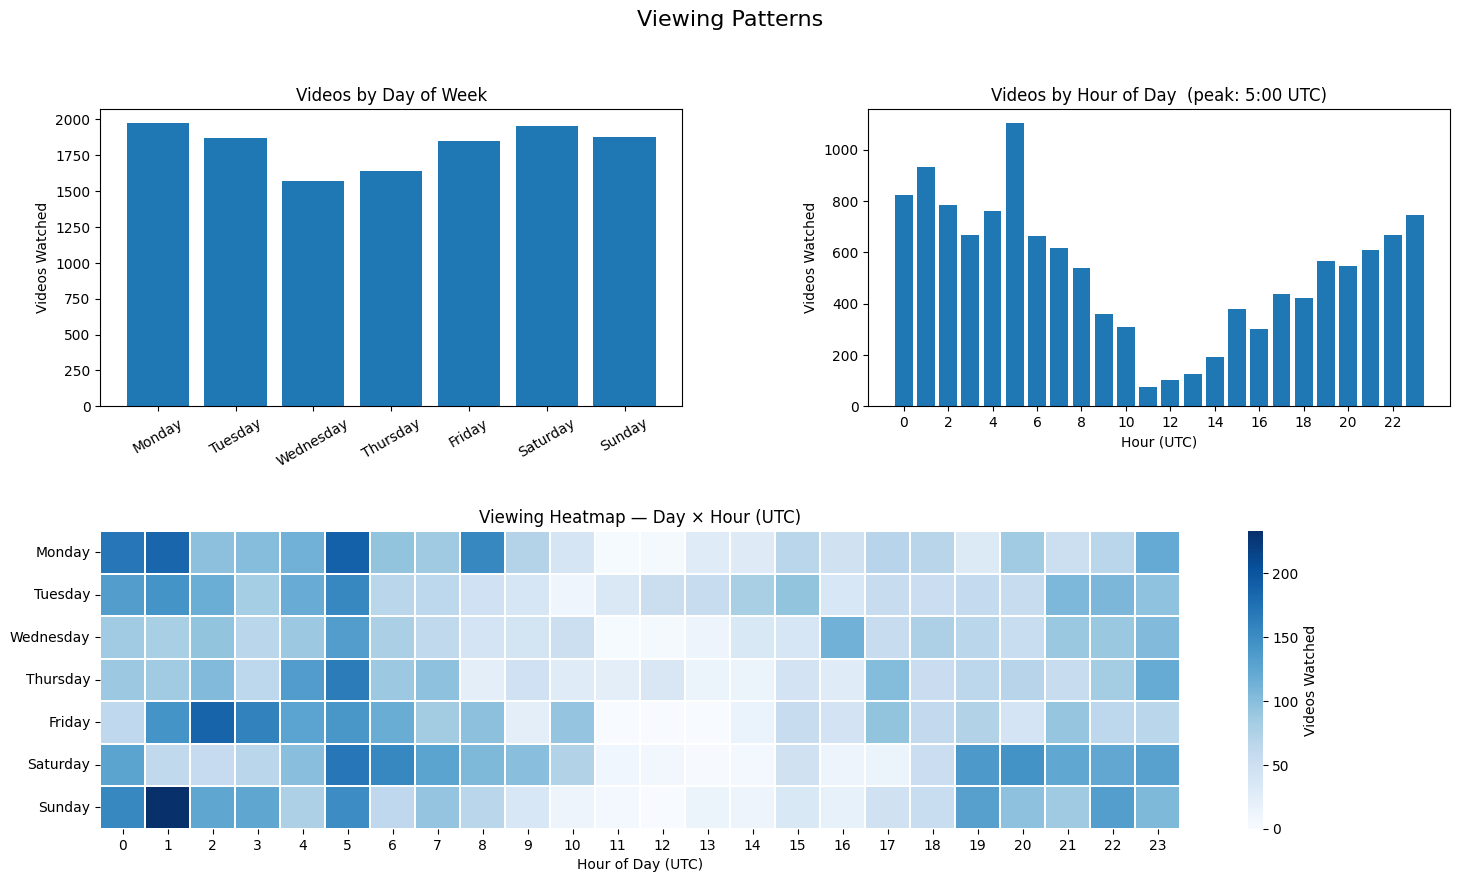

In [121]:
DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

watch_only = df[df["source"] == "watch"].copy()

# Day-of-week 
views_dow = (
    watch_only.groupby("day_of_week").size()
    .reindex(DOW_ORDER)
    .reset_index(name="views")
)

# Hour-of-day 
views_hour = (
    watch_only.groupby("hour").size()
    .reset_index(name="views")
    .sort_values("hour")
)
peak_hour = views_hour.loc[views_hour["views"].idxmax(), "hour"]

# Day × Hour heatmap 
heat = (
    watch_only.groupby(["day_of_week", "hour"]).size()
    .reset_index(name="count")
    .pivot(index="day_of_week", columns="hour", values="count")
    .reindex(DOW_ORDER)
    .fillna(0)
)

# Plot 
fig = plt.figure(figsize=(15, 9))
gs  = GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# Day of week
ax_a = fig.add_subplot(gs[0, 0])
ax_a.bar(views_dow["day_of_week"], views_dow["views"])
ax_a.set_title("Videos by Day of Week")
ax_a.set_ylabel("Videos Watched")
ax_a.tick_params(axis="x", rotation=30)

# Hour of day
ax_b = fig.add_subplot(gs[0, 1])
ax_b.bar(views_hour["hour"], views_hour["views"], width=0.8)
ax_b.set_title(f"Videos by Hour of Day  (peak: {peak_hour}:00 UTC)")
ax_b.set_xlabel("Hour (UTC)")
ax_b.set_ylabel("Videos Watched")
ax_b.set_xticks(range(0, 24, 2))

# Heatmap 
ax_c = fig.add_subplot(gs[1, :])
sns.heatmap(
    heat, cmap="Blues", linewidths=0.3, linecolor="white",
    ax=ax_c, cbar_kws={"label": "Videos Watched"},
    annot=False
)
ax_c.set_title("Viewing Heatmap — Day × Hour (UTC)")
ax_c.set_xlabel("Hour of Day (UTC)")
ax_c.set_ylabel("")
ax_c.tick_params(axis="x", rotation=0)

fig.suptitle("Viewing Patterns", fontsize=16, y=1.01)
fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.10, wspace=0.25, hspace=0.35)
plt.show()


## Viewing Patterns Insights

- Viewing activity is relatively consistent across the week, with slightly higher engagement toward the beginning and end of the week.
- Watching behavior is concentrated during late-night and early-morning hours, while midday activity is noticeably lower.
- The day–hour heatmap shows recurring viewing patterns rather than isolated spikes, suggesting stable usage habits over time.
- Evening and late-night periods appear to be the primary time window for YouTube consumption.

## 7. Content Preferences: Top Channels

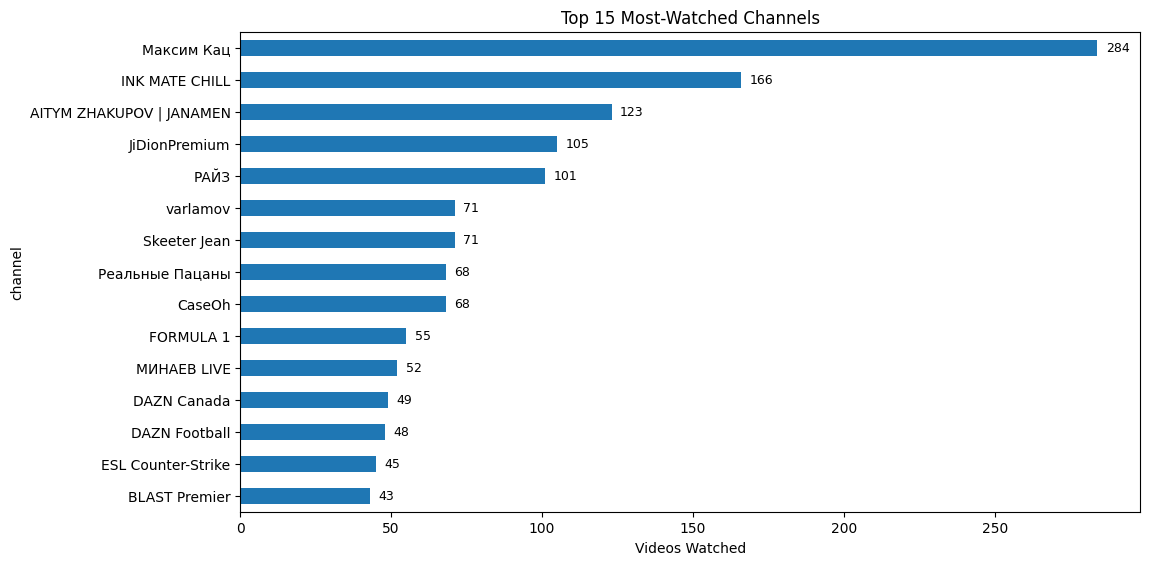

In [122]:
channel_rows = []
for item in watch_raw:
    subs = item.get("subtitles")
    if isinstance(subs, list) and subs:
        channel_rows.append({
            "time":    item.get("time"),
            "channel": subs[0].get("name"),
        })

ch_df = pd.DataFrame(channel_rows)
ch_df["time"]    = pd.to_datetime(ch_df["time"], errors="coerce", utc=True)
ch_df["channel"] = ch_df["channel"].str.strip()
ch_df = ch_df.dropna(subset=["time", "channel"])

top_channels = ch_df["channel"].value_counts().head(15)

# Bar chart 
fig, ax = plt.subplots(figsize=(10, 6))
top_channels.sort_values().plot(kind="barh", ax=ax)
for i, val in enumerate(top_channels.sort_values().values):
    ax.text(val + max(top_channels) * 0.01, i, f"{val:,}", va="center", fontsize=9)
ax.set_title("Top 15 Most-Watched Channels")
ax.set_xlabel("Videos Watched")
fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.10, wspace=0.25, hspace=0.35)
plt.show()

### Most-Watched Channels Insights

- The top 15 channels account for **17.5% of total videos watched**, indicating diversified viewing habits rather than reliance on a few creators.
- A small number of channels dominate individual watch counts, showing recurring engagement with preferred creators.
- The channel distribution reflects a mix of **entertainment, commentary, and sports-related content**.
- Most viewing activity is spread across many additional channels, reinforcing algorithm-driven discovery and varied interests.
- Overall, viewing behavior balances **loyal creator followership** with continuous exploration of new content.

# 8. Search Behaviour


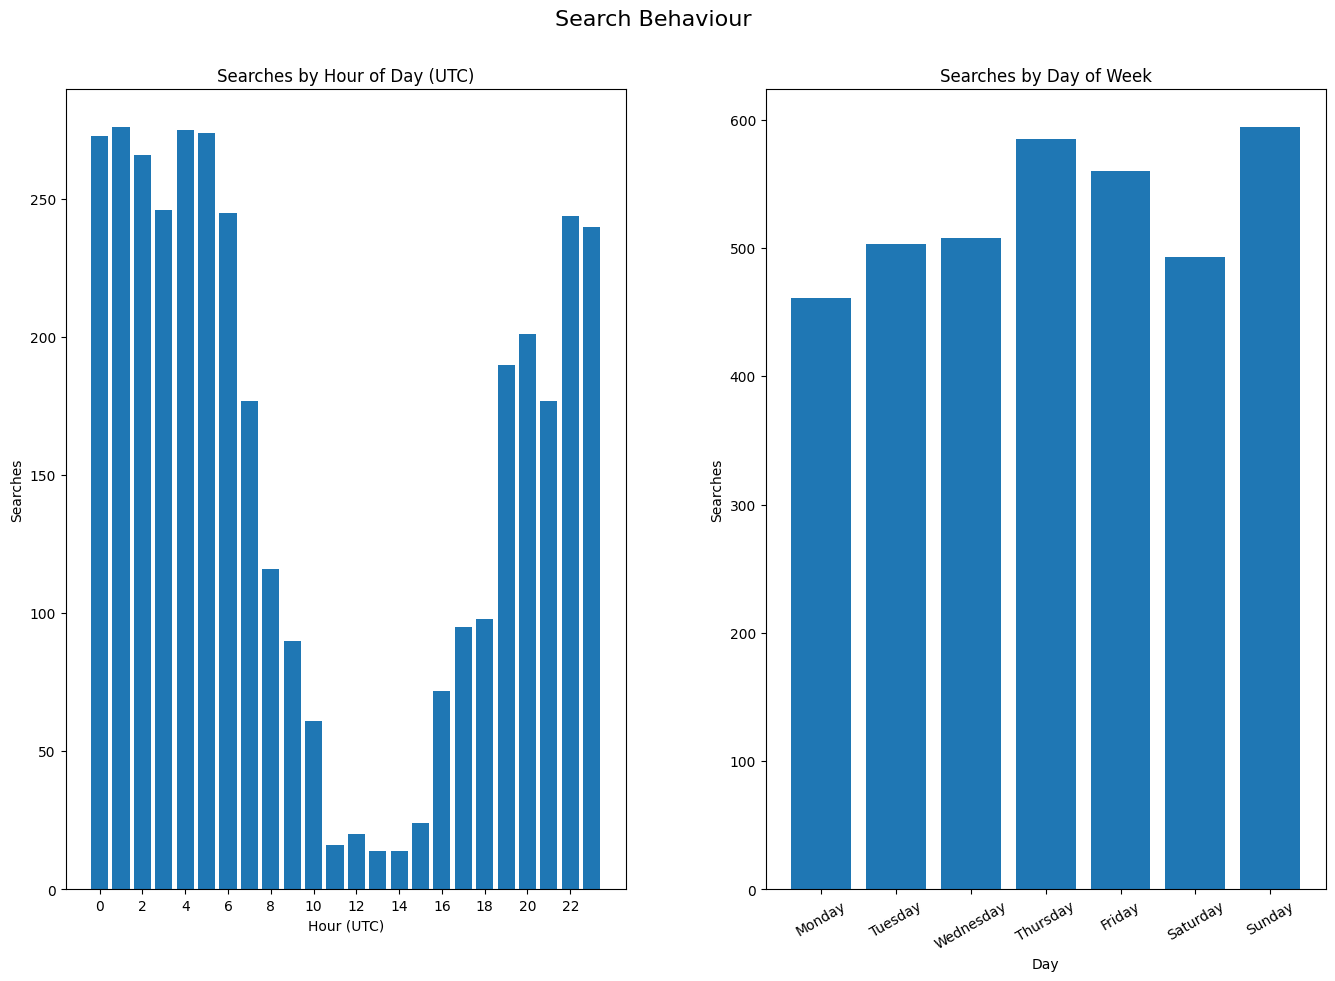

In [123]:
if search_df.empty:
    print("No search data available.")
else:
    # Timing 
    search_hour = search_df.groupby("hour").size()
    search_dow  = search_df.groupby("day_of_week").size().reindex(DOW_ORDER)

    # 2-panel plot 
    fig, axes = plt.subplots(1, 2, figsize=(14, 10))

    axes[0].bar(search_hour.index, search_hour.values, width=0.8)
    axes[0].set_title("Searches by Hour of Day (UTC)")
    axes[0].set_xlabel("Hour (UTC)")
    axes[0].set_ylabel("Searches")
    axes[0].set_xticks(range(0, 24, 2))

    axes[1].bar(search_dow.index, search_dow.values)
    axes[1].set_title("Searches by Day of Week")
    axes[1].set_xlabel("Day")
    axes[1].set_ylabel("Searches")
    axes[1].tick_params(axis="x", rotation=30)

    fig.suptitle("Search Behaviour", fontsize=16)
    fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.10, wspace=0.25, hspace=0.35)
    plt.show()

## Search Behavior Insights 

Search activity is concentrated during late night and early morning hours, with peak searches occurring between midnight and early morning (UTC), while activity drops significantly during midday. This pattern suggests searches are often performed during personal or leisure time rather than structured daytime hours.

Across the week, search behaviour remains relatively consistent, with slightly higher activity toward the end of the week, particularly on Thursday and Sunday. Overall, search usage appears habitual and evenly distributed rather than tied to a single specific day.

# 9. Year-over-Year & Binge Analysis
Three views:
1. Videos watched per year (bar)
2. Month × Year activity heatmap
3. Daily viewing distribution & top binge days

**Data Coverage Note:** 2026 counts are lower because the year is still in progress at export time. Interpret comparisons with prior full years cautiously.


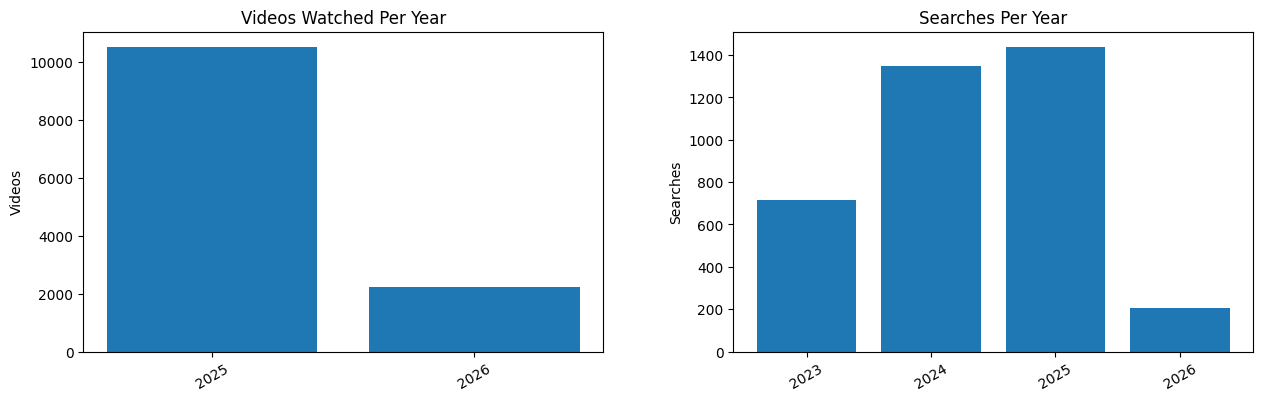

In [124]:
# Watches per year 
watch_year_counts = watch_df.groupby("year").size().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar([str(y) for y in watch_year_counts.index], watch_year_counts.values)
axes[0].set_title("Videos Watched Per Year")
axes[0].set_ylabel("Videos")
axes[0].tick_params(axis="x", rotation=30)

if not search_df.empty:
    search_year_counts = search_df.groupby("year").size().sort_index()
    axes[1].bar([str(y) for y in search_year_counts.index], search_year_counts.values)
    axes[1].set_title("Searches Per Year")
    axes[1].set_ylabel("Searches")
    axes[1].tick_params(axis="x", rotation=30)
else:
    axes[1].set_visible(False)

fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.10, wspace=0.25, hspace=0.35)
plt.show()


## Yearly Activity Insights

- Video consumption is significantly higher in **2025** compared to **2026**.
- As mentioned earlier, **2026 data is incomplete**, since it only includes activity up to **February 2026**, which explains the lower totals.
- Search activity increases from 2023 to 2025, suggesting growing reliance on YouTube for intentional content discovery.
- The combination of high watch counts and increasing searches indicates a shift toward more active and purposeful platform usage over time.
- Overall trends show expanding engagement before stabilizing in early 2026 due to partial-year data.

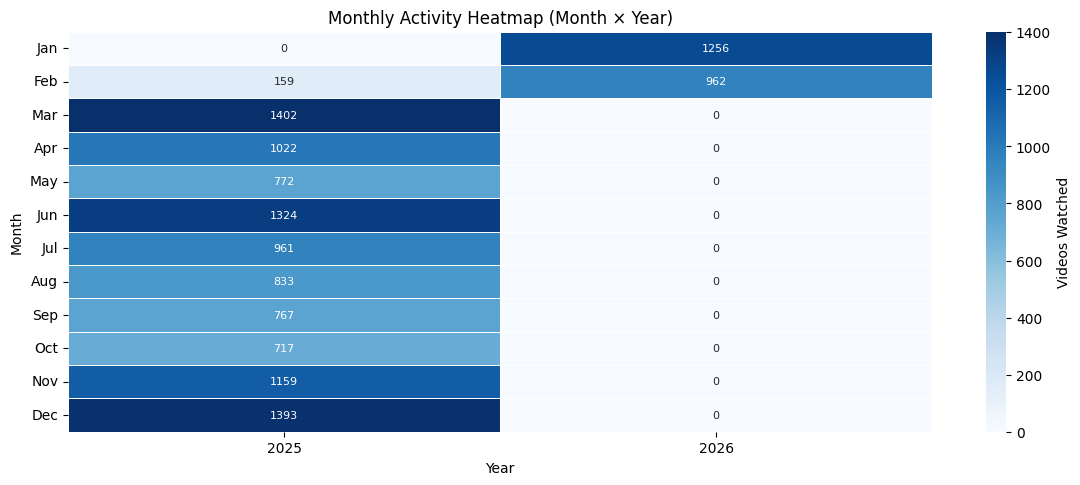

In [125]:
#  Month × Year heatmap 
watch_pivot = (
    watch_df.pivot_table(index="month_num", columns="year", aggfunc="size", fill_value=0)
    .sort_index()
)

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    watch_pivot, cmap="Blues",
    linewidths=0.4, linecolor="white",
    ax=ax, cbar_kws={"label": "Videos Watched"},
    annot=True, fmt="d", annot_kws={"size": 8}
)
ax.set_title("Monthly Activity Heatmap (Month × Year)")
ax.set_xlabel("Year")
ax.set_ylabel("Month")
ax.set_yticklabels(MONTH_NAMES, rotation=0)
fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.10, wspace=0.25, hspace=0.35)
plt.show()


## Monthly Activity Insights

- Viewing activity varies significantly across months, showing clear seasonal patterns.
- The highest engagement occurs toward the **end of 2025**, peaking in **November and December**.
- Activity levels in **2026** differ from previous months and remain a subject for future analysis as viewing patterns continue to evolve.
- Mid-year months maintain steady but moderate viewing levels.
- Overall, viewing behavior appears **period-based**, with spikes likely linked to free time, holidays, or lifestyle changes.

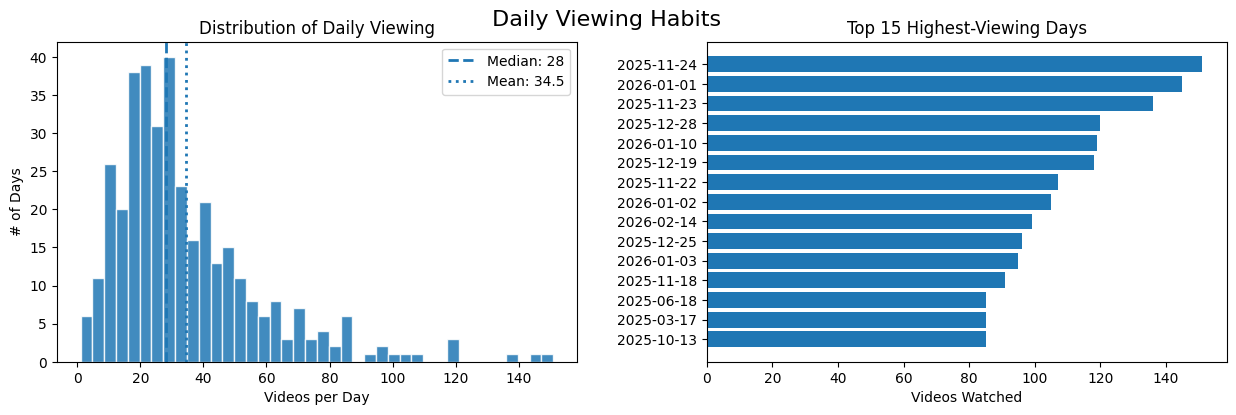

In [126]:
# Analyze daily viewing habits
daily_counts = watch_df.groupby("date").size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

#Distribution of daily counts
axes[0].hist(daily_counts.values, bins=40, edgecolor="white", alpha=0.85)
axes[0].axvline(daily_counts.median(), lw=2, ls="--", label=f"Median: {daily_counts.median():.0f}")
axes[0].axvline(daily_counts.mean(), lw=2, ls=":", label=f"Mean: {daily_counts.mean():.1f}")
axes[0].set_title("Distribution of Daily Viewing")
axes[0].set_xlabel("Videos per Day")
axes[0].set_ylabel("# of Days")
axes[0].legend()

#Top 15 Highest-Viewing Days
top_days = daily_counts.sort_values(ascending=False).head(15)
axes[1].barh([str(d) for d in top_days.index[::-1]], top_days.values[::-1])
axes[1].set_title("Top 15 Highest-Viewing Days")
axes[1].set_xlabel("Videos Watched")

fig.suptitle(" Daily Viewing Habits", fontsize=16)
fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.10, wspace=0.25, hspace=0.35)
plt.show()


## Viewing Habits Insights

- Average viewing is **34.5 videos per day**, showing consistent daily engagement.
- Median viewing (**28 videos/day**) suggests most days involve moderate usage.
- The distribution is **right-skewed**, meaning a few binge days raise the overall average.
- The highest activity day reached **151 videos**, indicating occasional binge-watching sessions.
- Overall behavior reflects a mix of **steady daily consumption** and periodic high-intensity viewing.

# 10.Content Theme Analysis

Category distribution:
category
Other / Uncategorized        4670
Gaming                       1731
Tech & Science               1617
Sports                        811
Education & How-To            727
Film & Animation              564
Automotive                    457
News & Politics               308
Comedy & Entertainment        263
Finance & Business            259
Music                         233
History                       229
Vlogs & Lifestyle             144
Short-form & Social Media      75
Food & Cooking                 54


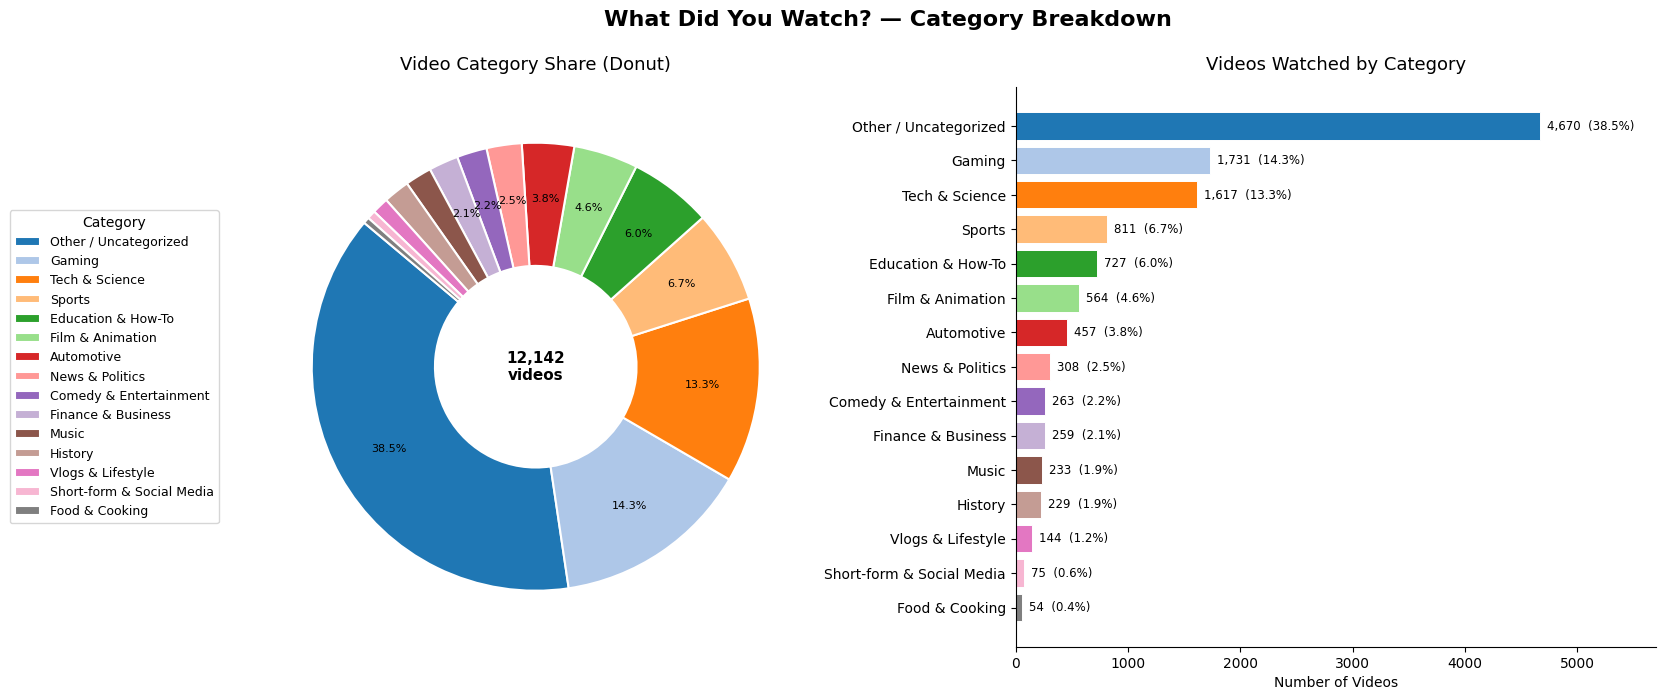

In [127]:
CATEGORY_KEYWORDS = {
    "Gaming": {
        "en": [
            "game", "gaming", "gameplay", "walkthrough", "playthrough", "speedrun",
            "minecraft", "fortnite", "roblox", "gta", "valorant", "counter-strike",
            "csgo", "cs2", "pubg", "warzone", "apex", "rocket league", "league of legends",
            "dota", "overwatch", "zelda", "mario", "pokemon",
            "ranked", "competitive", "esports", "pro match", "patch", "meta",
            "fifa", "fut", "draft", "ultimate team", "pack opening", "career mode"
        ],
        "ru": [
            "игра", "игры", "геймплей", "прохождение", "стрим", "стример",
            "киберспорт", "ранкед", "соревновательный",
            "кс", "ксго", "кс 2", "cs2", "фифа", "fifa", "фут", "пак", "паки"
        ],
    },

    "Sports": {
        "en": [
            "sport", "football", "soccer", "nba", "nfl", "nhl",
            "basketball", "hockey", "tennis", "boxing", "mma", "ufc",
            "highlights", "goal", "match", "tournament", "championship",
            "league", "playoffs", "premier league", "la liga", "ucl", "champions league",
            "whitecaps", "canucks", "barcelona", "manchester", "liverpool", "real madrid", "juventus"
        ],
        "ru": [
            "спорт", "футбол", "хоккей", "баскетбол", "теннис", "бокс", "мма", "ufc",
            "обзор", "хайлайты", "матч", "турнир", "чемпионат", "лига",
        ],
    },

    "Music": {
        "en": [
            "music", "song", "lyrics", "official video", "official music video",
            "mv", "album", "concert", "live performance", "remix", "instrumental",
            "dj set", "cover", "playlist"
        ],
        "ru": [
            "музыка", "песня", "клип", "альбом", "концерт", "ремикс", "кавер", "текст"
        ],
    },

    "Comedy & Entertainment": {
        "en": [
            "funny", "comedy", "meme", "memes", "prank", "challenge", "reaction",
            "try not to laugh", "roast", "sketch", "parody", "fail", "compilation"
        ],
        "ru": [
            "смешно", "прикол", "юмор", "реакция", "пранк", "челлендж", "подборка"
        ],
    },

    "History": {
        "en": [
            "history", "historical", "documentary", "timeline", "ancient", "medieval",
            "empire", "civilization", "world war", "ww1", "ww2", "cold war",
            "battle", "biography", "archive", "rise and fall", "explained",
            "historian", "chronicle", "reconstruction"
        ],
        "ru": [
            "история", "исторический", "документальный", "реконструкция",
            "первая мировая", "вторая мировая", "холодная война",
            "империя", "цивилизация", "битва", "биография", "архив",
            "историк", "летопись"
        ],
    },

    "Education & How-To": {
        "en": [
            "tutorial", "how to", "explained", "learn", "course", "lesson", "guide",
            "tips", "study", "lecture", "university", "exam", "assignment",
            "homework", "practice"
        ],
        "ru": [
            "урок", "обучение", "как", "объяснение", "лекция", "университет", "экзамен",
            "домашка", "практика", "разбор"
        ],
    },

    "Tech & Science": {
        "en": [
            "tech", "technology", "programming", "coding", "python", "javascript",
            "ai", "artificial intelligence", "machine learning", "data science",
            "science", "physics", "space", "nasa", "review", "unboxing",
            "hardware", "software", "linux", "windows", "iphone", "android", "gpu", "cpu",
            "algorithm", "model", "computer"
        ],
        "ru": [
            "технологии", "техника", "программирование", "кодинг", "питон",
            "ии", "искусственный интеллект", "машинное обучение",
            "наука", "физика", "космос", "обзор", "распаковка",
            "алгоритм", "модель", "компьютер"
        ],
    },

    "Vlogs & Lifestyle": {
        "en": [
            "vlog", "day in my life", "week in my life", "lifestyle", "daily routine",
            "travel", "trip", "vacation", "moving", "room tour", "q&a",
            "morning routine", "night routine"
        ],
        "ru": [
            "влог", "жизнь", "день из жизни", "неделя из жизни", "путешествие",
            "переезд", "румтур", "рутина", "вопросы и ответы"
        ],
    },

    "News & Politics": {
        "en": [
            "news", "breaking", "politics", "election", "government",
            "analysis", "debate", "interview", "press conference", "world news",
            "ukraine", "russia", "israel", "iran", "sanctions"
        ],
        "ru": [
            "новости", "политика", "выборы", "государство",
            "анализ", "дебаты", "интервью", "пресс-конференция",
            "украина", "россия", "израиль", "иран", "санкции"
        ],
    },

    "Finance & Business": {
        "en": [
            "investing", "stocks", "crypto", "bitcoin", "finance", "money",
            "business", "startup", "trading", "economy", "market",
            "entrepreneur", "portfolio"
        ],
        "ru": [
            "деньги", "инвестиции", "акции", "крипто", "биткоин", "финансы",
            "бизнес", "стартап", "трейдинг", "экономика", "рынок",
            "предприниматель", "портфель"
        ],
    },

    "Food & Cooking": {
        "en": [
            "recipe", "cooking", "food", "baking", "chef", "restaurant",
            "street food", "taste test", "cuisine", "kitchen"
        ],
        "ru": [
            "рецепт", "еда", "готовка", "выпечка", "шеф", "ресторан", "кухня",
            "вкус", "дегустация"
        ],
    },

    "Film & Animation": {
        "en": [
            "movie", "film", "trailer", "anime", "animation", "series", "episode",
            "cinema", "netflix", "scene", "edit", "shorts", "#shorts",
            "review", "ending explained"
        ],
        "ru": [
            "кино", "фильм", "сериал", "аниме", "мульт", "сцена", "трейлер",
            "эдит", "шортс", "#шортс",
            "обзор", "разбор концовки"
        ],
    },

    "Automotive": {
        "en": [
            "car", "cars", "automobile", "test drive", "engine", "drift", "racing",
            "bmw", "mercedes", "tesla", "toyota", "honda", "ford", "jdm",
            "lamborghini", "ferrari"
        ],
        "ru": [
            "машина", "авто", "тачка", "тест-драйв", "двигатель", "дрифт", "гонки",
            "обзор авто"
        ],
    },

    "Short-form & Social Media": {
        "en": ["shorts", "#shorts", "tiktok", "reels", "viral", "trend", "edit", "clip"],
        "ru": ["шортс", "#шортс", "тикток", "рилс", "вирусное", "тренд", "эдит", "клип"],
    },
}

def _normalize_text(s: str) -> str:
    # Standardize text for keyword matching
    """Lower + collapse whitespace for consistent matching."""
    s = str(s or "").lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

def classify_video(row):
    # Robustly get title and channel, then combine for keyword matching
    title = row.get("video_title") or row.get("clean_title") or row.get("title") or ""
    channel = row.get("channel_name") or row.get("channel") or ""
    text = _normalize_text(f"{title} {channel}")

    for category, lang_dict in CATEGORY_KEYWORDS.items():
        if any(kw in text for kw in lang_dict["en"]) or any(kw in text for kw in lang_dict["ru"]):
            return category

    return "Other / Uncategorized"

# Build watch-only frame for categorization (searches don't have titles/channels)
watch_only = df[df["source"] == "watch"].copy()

# Detect title/channel column names present
title_col = "video_title" if "video_title" in watch_only.columns else ("clean_title" if "clean_title" in watch_only.columns else "title")
channel_col = "channel_name" if "channel_name" in watch_only.columns else "channel"

# Filter out ads / shortened / non-content entries
watch_only = watch_only[
    ~watch_only[title_col].astype(str).str.contains(
        r"Shortened:|From Google Ads|Advertisement|Ads",
        case=False,
        na=False
    )
].copy()

# Drop empty titles
watch_only = watch_only[watch_only[title_col].notna()].copy()

# First-pass categorization
watch_only["category"] = watch_only.apply(classify_video, axis=1)

# Improve categorization: channel-based fallback
channel_major_category = (
    watch_only[watch_only["category"] != "Other / Uncategorized"]
    .groupby(channel_col)["category"]
    .agg(lambda x: x.value_counts().idxmax())
)

def improve_category(row):
    if row["category"] != "Other / Uncategorized":
        return row["category"]
    return channel_major_category.get(row[channel_col], "Other / Uncategorized")

watch_only["category"] = watch_only.apply(improve_category, axis=1)

# Distribution
cat_counts = watch_only["category"].value_counts()
cat_pct = (cat_counts / cat_counts.sum() * 100).round(1)

print("Category distribution:")
print(cat_counts.to_string())

# Plotting
PALETTE = sns.color_palette("tab20", n_colors=len(cat_counts))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Donut chart
ax_pie = axes[0]
wedges, texts, autotexts = ax_pie.pie(
    cat_counts.values,
    labels=None,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 2 else "",
    startangle=140,
    colors=PALETTE,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=1.5),
    pctdistance=0.75,
)

for at in autotexts:
    at.set_fontsize(8)

ax_pie.legend(
    wedges, cat_counts.index,
    title="Category", loc="center left",
    bbox_to_anchor=(-0.45, 0.5), fontsize=9, title_fontsize=10
)
ax_pie.set_title("Video Category Share (Donut)", fontsize=13, pad=12)

total = int(cat_counts.sum())
ax_pie.text(
    0, 0, f"{total:,}\nvideos",
    ha="center", va="center", fontsize=11, fontweight="bold"
)

# Horizontal bar chart
ax_bar = axes[1]
sorted_cats = cat_counts.sort_values()
bars = ax_bar.barh(
    sorted_cats.index,
    sorted_cats.values,
    color=PALETTE[::-1],
    edgecolor="white", linewidth=0.7
)

for bar, val, pct in zip(bars, sorted_cats.values, cat_pct[sorted_cats.index].values):
    ax_bar.text(
        bar.get_width() + total * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}  ({pct}%)",
        va="center", fontsize=8.5
    )

ax_bar.set_title("Videos Watched by Category", fontsize=13, pad=12)
ax_bar.set_xlabel("Number of Videos")
ax_bar.set_xlim(right=sorted_cats.max() * 1.22)
ax_bar.spines[["top", "right"]].set_visible(False)

fig.suptitle("What Did You Watch? — Category Breakdown", fontsize=16, fontweight="bold", y=1.01)
fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.10, wspace=0.25, hspace=0.35)
plt.show()

## Video Category Insights
The viewing history shows a diverse consumption pattern, suggesting algorithm-driven exploration rather than niche-focused watching. After refining keyword rules and applying channel-based fallback classification, the share of uncategorized videos decreased from 58% to 38.5%, improving dataset clarity.

Among defined categories, Tech & Science, Education & How-To, and Sports dominate, indicating a balance between learning-oriented content and entertainment. The remaining uncategorized videos reflect the limitations of keyword-based classification when titles contain little descriptive information.

Overall, YouTube serves both as an educational resource and a source of casual entertainment, with viewing behavior spread across many smaller content categories.

# 11. Exporting

## Export Privacy-Safe Outputs

This section exports aggregated datasets that contain no personal
watch history details. These files can safely be included in the
public GitHub repository.

In [128]:
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "data_processed"
OUTPUT_DIR.mkdir(exist_ok=True)

# Watch counts by year
watch_counts_by_year = (
    watch_df.groupby("year")
    .size()
    .reset_index(name="watch_count")
)

watch_counts_by_year.to_csv(
    OUTPUT_DIR / "watch_counts_by_year.csv",
    index=False
)

# Search counts by year
if not search_df.empty:
    search_counts_by_year = (
        search_df.groupby("year")
        .size()
        .reset_index(name="search_count")
    )

    search_counts_by_year.to_csv(
        OUTPUT_DIR / "search_counts_by_year.csv",
        index=False
    )

# Top channels
top_channels_df = top_channels.reset_index()
top_channels_df.columns = ["channel", "watch_count"]

top_channels_df.to_csv(
    OUTPUT_DIR / "top_channels_top15.csv",
    index=False
)

# Export category summary
category_summary = (
    pd.DataFrame({
        "category": cat_counts.index,
        "video_count": cat_counts.values,
        "percent": cat_pct.values
    })
    .sort_values("video_count", ascending=False)
    .reset_index(drop=True)
)

category_summary.to_csv(OUTPUT_DIR / "video_category_breakdown.csv", index=False)
print("Exports saved to:", OUTPUT_DIR)

Exports saved to: c:\Users\aisen\Documents\youtube-behavior-analysis\notebooks\data_processed
